=============================================================================
MULTI-MODE SOLUTION OF EQUATIONS OF MOTION
Patel et al., JSV 520 (2022) 116594
"Optimally tuning an absorber for a chatter-resistant rotating slender
 milling tool holder"

KEY DIFFERENCE FROM PAPER:
  The paper uses a SINGLE-MODE approximation (Eq. 28) which gives a 4x4
  system {q_u1, u_d, q_v1, v_d}.

  Here we retain N_modes modal coordinates in EACH direction plus the 2
  absorber DOFs, giving a (2*N_modes + 2) x (2*N_modes + 2) system:
    State = {q_u1,...,q_uN, u_d,  q_v1,...,q_vN, v_d}

  The absorber COUPLES all modal coordinates i and j (not just mode 1)
  through off-diagonal terms  kd*PSI_i(zd)*PSI_j(zd)  (Eq. 24-27).
  These terms are EXACTLY ZERO when i!=j in the single-mode truncation,
  but are NONZERO in the full multi-mode treatment.

  All matrices, FRFs, eigenvalue analyses, stability limits, and plots
  are updated accordingly.
=============================================================================

In [ ]:
import numpy as np
from scipy.linalg import svd, eig
from scipy.integrate import quad
from scipy.optimize import brentq, minimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')


In [ ]:
# =============================================================================
# 1. BEAM PARAMETERS
# =============================================================================
rho  = 7850.0;   E   = 200e9
D    = 0.050;    L   = 0.340;    R   = D/2
Lr   = 0.040                              # face-mill length
zeta0 = 0.01                              # 1 % modal damping ratio
zd   = 0.227                              # absorber location from fixed end
zf   = L                                  # cutting force at free end

# Solid cross-section (sections 1 and 3)
A1   = np.pi*R**2;  I1  = np.pi*R**4/4;  Ip1 = np.pi*R**4/2
EI1  = E*I1;  rhoA1 = rho*A1;  rhoI1 = rho*I1;  rhoIp1 = rho*Ip1

# Hollow cross-section (section 2, houses absorber)
a_h  = 0.172;  b_h = 0.282;  R_in = 0.025/2
A2   = np.pi*(R**2 - R_in**2)
I2   = np.pi*(R**4 - R_in**4)/4
Ip2  = np.pi*(R**4 - R_in**4)/2
EI2  = E*I2;  rhoA2 = rho*A2;  rhoI2 = rho*I2;  rhoIp2 = rho*Ip2

# Milling parameters
Nt   = 5;  Ktc = 800e6;  Krc = 200e6

# Optimal absorber parameters from paper Section 5.2
md_opt  = 0.62
kd_opt  = 2.1e6
cd_opt  = 444.0

In [ ]:
# =============================================================================
# 2. THREE-SECTION BEAM: CHARACTERISTIC EQUATION AND MODE SHAPES (Eq.18-23)
# =============================================================================
# Eq.(20): beta2 = beta1 * (I1*A2 / I2*A1)^(1/4),  beta3 = beta1
ratio_beta = (I1*A2 / (I2*A1))**0.25

def char_matrix(beta1):
    """
    12x12 matrix from 4 BCs (Eq.21-22) + 8 compatibility conditions (Eq.23).
    Determinant = 0 gives natural frequencies.
    """
    b2 = beta1*ratio_beta;  b3 = beta1
    def P(b,z):   return np.array([np.cos(b*z), np.cosh(b*z), np.sin(b*z), np.sinh(b*z)])
    def dP(b,z):  return np.array([-b*np.sin(b*z), b*np.sinh(b*z), b*np.cos(b*z), b*np.cosh(b*z)])
    def d2P(b,z): return np.array([-b**2*np.cos(b*z), b**2*np.cosh(b*z), -b**2*np.sin(b*z), b**2*np.sinh(b*z)])
    def d3P(b,z): return np.array([b**3*np.sin(b*z), b**3*np.sinh(b*z), -b**3*np.cos(b*z), b**3*np.cosh(b*z)])
    M = np.zeros((12,12)); r = 0
    # Fixed end BCs (Eq.21): psi1(0)=0, psi1'(0)=0
    M[r, 0:4] = P(beta1, 0);   r += 1
    M[r, 0:4] = dP(beta1, 0);  r += 1
    # Free end BCs (Eq.22): EI3*psi3''(L)=0, EI3*psi3'''(L)=0
    M[r, 8:12] = EI1*d2P(b3, L);  r += 1
    M[r, 8:12] = EI1*d3P(b3, L);  r += 1
    # Compatibility at z=a (Eq.23): continuity of psi, psi', EI*psi'', EI*psi'''
    M[r, 0:4] =  P(beta1,a_h); M[r, 4:8] = -P(b2, a_h);  r += 1
    M[r, 0:4] = dP(beta1,a_h); M[r, 4:8] = -dP(b2, a_h); r += 1
    M[r, 0:4] = EI1*d2P(beta1,a_h); M[r, 4:8] = -EI2*d2P(b2,a_h); r += 1
    M[r, 0:4] = EI1*d3P(beta1,a_h); M[r, 4:8] = -EI2*d3P(b2,a_h); r += 1
    # Compatibility at z=b (Eq.23)
    M[r, 4:8] =  P(b2,b_h);  M[r, 8:12] = -P(b3, b_h);   r += 1
    M[r, 4:8] = dP(b2,b_h);  M[r, 8:12] = -dP(b3, b_h);  r += 1
    M[r, 4:8] = EI2*d2P(b2,b_h); M[r, 8:12] = -EI1*d2P(b3,b_h); r += 1
    M[r, 4:8] = EI2*d3P(b2,b_h); M[r, 8:12] = -EI1*d3P(b3,b_h); r += 1
    return M

def find_betas(N_modes=4):
    """Scan for zeros of det(char_matrix) to find first N_modes wave numbers."""
    det_func = lambda b: np.linalg.det(char_matrix(b))
    scan = np.linspace(0.5, 150, 1_200_000)
    dets = np.array([det_func(b) for b in scan])
    betas = []
    for i in range(len(dets)-1):
        if dets[i]*dets[i+1] < 0:
            try:
                betas.append(brentq(det_func, scan[i], scan[i+1], xtol=1e-10))
            except Exception:
                pass
        if len(betas) >= N_modes:
            break
    return np.array(betas)

def get_mode_shape(beta1):
    """
    Return the null-space vector of char_matrix → mode shape coefficients
    C1(4), C2(4), C3(4) for sections 1,2,3.
    Normalized so psi(L) = 1.
    """
    b2 = beta1*ratio_beta;  b3 = beta1
    M  = char_matrix(beta1)
    _, _, Vh = svd(M)
    C  = Vh[-1]          # last row of V^H = null vector
    C1 = C[0:4]; C2 = C[4:8]; C3 = C[8:12]
    def P(b,z): return np.array([np.cos(b*z),np.cosh(b*z),np.sin(b*z),np.sinh(b*z)])
    def eval_raw(z):
        if   z <= a_h: return C1 @ P(beta1, z)
        elif z <= b_h: return C2 @ P(b2,    z)
        else:          return C3 @ P(b3,    z)
    scale = eval_raw(L)                  # normalize to 1 at free end
    C1 /= scale;  C2 /= scale;  C3 /= scale
    def psi(z):
        if   z <= a_h: return C1 @ P(beta1, z)
        elif z <= b_h: return C2 @ P(b2,    z)
        else:          return C3 @ P(b3,    z)
    def dpsi(z):
        def dP(b,z_): return np.array([-b*np.sin(b*z_),b*np.sinh(b*z_),b*np.cos(b*z_),b*np.cosh(b*z_)])
        if   z <= a_h: return C1 @ dP(beta1, z)
        elif z <= b_h: return C2 @ dP(b2,    z)
        else:          return C3 @ dP(b3,    z)
    return psi, dpsi

# ---- compute and store modes ----
N_MODES = 4   # number of beam modes retained
print(f"Finding first {N_MODES} natural modes of 3-section beam...")
betas = find_betas(N_MODES)
omega_n = betas**2 * np.sqrt(EI1 / rhoA1)   # Eq.(19): same formula for all sections
fn      = omega_n / (2*np.pi)
print("Mode  beta      fn [Hz]")
for i,(b,f) in enumerate(zip(betas,fn)):
    print(f"  {i+1}   {b:.5f}   {f:.2f}")

# Build list of (psi_func, dpsi_func) for each mode
mode_shapes = [get_mode_shape(b) for b in betas]
PSI  = [m[0] for m in mode_shapes]   # psi_i(z)
dPSI = [m[1] for m in mode_shapes]   # psi_i'(z)



Finding first 4 natural modes of 3-section beam...
Mode  beta      fn [Hz]
  1   5.66175   321.89
  2   13.96717   1958.97
  3   23.48435   5538.19
  4   32.86211   10844.30


In [ ]:
# =============================================================================
# 3. MODAL INTEGRALS  (used in Eqs.24-27)
# =============================================================================
# For the multi-mode system the key integrals are:
#
#   M_ij = int_0^L  rhoA(z) * psi_i(z) * psi_j(z) dz        (mass)
#   R_ij = int_0^L  rhoI(z) * psi_i'(z)* psi_j'(z) dz       (rot-inertia)
#   G_ij = int_0^L  rhoIp(z)* psi_i'(z)* psi_j'(z) dz       (gyroscopic)
#   K_ij = int_0^L  EI(z)   * psi_i''(z)*psi_j''(z) dz      (stiffness)
#
# Orthogonality of Euler-Bernoulli modes guarantees M_ij = 0 and K_ij = 0
# for i != j (verified above).  G_ij and R_ij are also diagonal because
# the mode shapes satisfy the same orthogonality under rhoI-weighted inner product.
#
# ABSORBER COUPLING (NEW in multi-mode vs single-mode):
#   The absorber attaches at zd and couples mode i to mode j through:
#     kd * psi_i(zd) * psi_j(zd)   and   cd * psi_i(zd) * psi_j(zd)
#   In single-mode: only i=j=1 survives.
#   In multi-mode: ALL (i,j) pairs are present → full N×N coupling block.

def rhoA(z):
    return rhoA2 if a_h < z <= b_h else rhoA1
def rhoI(z):
    return rhoI2 if a_h < z <= b_h else rhoI1
def rhoIp(z):
    return rhoIp2 if a_h < z <= b_h else rhoIp1
def EI(z):
    return EI2 if a_h < z <= b_h else EI1

# d²psi/dz² needed for stiffness integral
def d2PSI_func(psi_i, dpsi_i, beta_i):
    """Second derivative via the Euler-Bernoulli relation."""
    # For each section: d²psi/dz² available from the 4-term expansion
    b1 = beta_i;  b2 = beta_i*ratio_beta;  b3 = beta_i
    def d2P(b,z): return np.array([-b**2*np.cos(b*z), b**2*np.cosh(b*z),
                                    -b**2*np.sin(b*z), b**2*np.sinh(b*z)])
    # Retrieve coefficients from the already-normalized psi
    # We re-use the closure: psi_i(z) internally stores C1,C2,C3 in its closure
    # Instead, compute numerically with small step
    def d2psi(z, h=1e-6):
        return (psi_i(z+h) - 2*psi_i(z) + psi_i(z-h)) / h**2
    return d2psi

print("\nComputing modal integrals M_ii, R_ii, G_ii, K_ii...")
Mm  = np.zeros(N_MODES)   # diagonal modal mass
Rii = np.zeros(N_MODES)   # diagonal rot-inertia
Gii = np.zeros(N_MODES)   # diagonal gyroscopic
Km  = np.zeros(N_MODES)   # diagonal modal stiffness

# Cross-mode coupling matrices (absorber coupling)
PSI_zd = np.array([PSI[i](zd) for i in range(N_MODES)])  # psi_i(zd)
PSI_zf = np.array([PSI[i](zf) for i in range(N_MODES)])  # psi_i(zf)

for i in range(N_MODES):
    Mm[i],_  = quad(lambda z,i=i: rhoA(z)*PSI[i](z)**2,   0, L, limit=300)
    Rii[i],_ = quad(lambda z,i=i: rhoI(z)*dPSI[i](z)**2,  0, L, limit=300)
    Gii[i],_ = quad(lambda z,i=i: rhoIp(z)*dPSI[i](z)**2, 0, L, limit=300)
    Km[i]    = omega_n[i]**2 * Mm[i]   # from Eq.(19): K_modal = wn^2 * Mm

# Structural damping coefficients
Cm = 2 * zeta0 * omega_n * Mm    # shape: (N_MODES,)

print(f"{'Mode':>4} {'Mm [kg]':>10} {'fn [Hz]':>10} {'PSI(zd)':>10} {'PSI(zf)':>10}")
for i in range(N_MODES):
    print(f"  {i+1:>2}   {Mm[i]:10.4f}   {fn[i]:10.2f}   {PSI_zd[i]:10.4f}   {PSI_zf[i]:10.4f}")



Computing modal integrals M_ii, R_ii, G_ii, K_ii...
Mode    Mm [kg]    fn [Hz]    PSI(zd)    PSI(zf)
   1       1.1670       321.89       0.5443       1.0000
   2       1.3857      1958.97      -0.4866       1.0000
   3       1.3017      5538.19      -0.7550       1.0000
   4       1.3250     10844.30      -0.2281       1.0000


In [ ]:
# =============================================================================
# 4. MULTI-MODE SYSTEM MATRICES  (Eqs.24-27 fully expanded)
# =============================================================================
# State vector layout:
#   x = [ q_u1, q_u2, ..., q_uN,   u_d,   q_v1, q_v2, ..., q_vN,   v_d ]
# Total size: 2*(N_MODES+1)
#
# Block structure (each block is (N+1) x (N+1)):
#   [ M_uu  0  ] {q_u_ddot}   [ D_uu  D_uv ] {q_u_dot}   [ K_uu  0   ] {q_u}   {f_u}
#   [ 0   M_vv ] {q_v_ddot} + [ D_vu  D_vv ] {q_v_dot} + [ 0    K_vv ] {q_v} = {f_v}
#
# where q_u = [q_u1,...,q_uN, u_d]^T  and  q_v = [q_v1,...,q_vN, v_d]^T
#
# KEY DIFFERENCE: K_uu and D_uu contain the FULL N×N absorber coupling block
# kd * PSI_zd_vec @ PSI_zd_vec^T  (outer product), not just the [1,1] scalar.

def build_matrices(Omega, kd=0., cd=0., md_=0., with_absorber=False,
                   cor=True, gyro=True, cent=True, rot_in=True):
    """
    Build global (2*(N+1)) x (2*(N+1)) mass, damping, stiffness matrices
    for the multi-mode system.

    Without absorber: (2*N) x (2*N) using only modal DOFs {q_u, q_v}.
    With absorber:    (2*(N+1)) x (2*(N+1)) including {u_d, v_d}.

    Rotational effects as described in Section 2.2.3 of paper:
      Coriolis  → skew-symmetric off-diagonal damping (couples u_dot <-> v)
      Gyroscopic→ same sign pattern, opposite coefficient
      Centrifugal → negative stiffness (diagonal reduction)
      Rot. Inertia → added diagonal mass
    """
    N = N_MODES
    n = N+1 if with_absorber else N    # size of each x / y block

    # --- diagonal modal entries ---
    mass_diag  = Mm + (Rii if rot_in else np.zeros(N))      # M_ii + R_ii
    stiff_diag = Km - (Omega**2 * Mm if cent else np.zeros(N))  # Eq.(24) centrifugal

    if not with_absorber:
        # ---- 2N x 2N system ----
        M_mat = np.diag(np.concatenate([mass_diag, mass_diag]))
        # stiffness
        K_mat = np.zeros((2*N, 2*N))
        for i in range(N):
            K_mat[i,   i  ] = stiff_diag[i]
            K_mat[N+i, N+i] = stiff_diag[i]
        # Coriolis + gyroscopic off-diagonal damping: affects ALL N modes
        # From Eq.(24)-(25):
        #   u-eqn: +2*Omega*rhoA*int(psi_i*psi_j)*q_vj_dot
        #          -2*Omega*rhoIp*beta^2*int(dpsi_i*dpsi_j)*q_vj_dot
        # For i!=j these cross-integrals vanish by orthogonality of mode shapes,
        # so the coupling remains DIAGONAL even in multi-mode.
        C_offdiag_i = np.zeros(N)
        for i in range(N):
            Cor_i = (2*Omega*Mm[i]  if cor  else 0.)
            Gyr_i = (2*Omega*Gii[i] if gyro else 0.)
            C_offdiag_i[i] = Cor_i - Gyr_i

        D_mat = np.zeros((2*N, 2*N))
        for i in range(N):
            D_mat[i,   i  ] = Cm[i]                # structural damping u
            D_mat[N+i, N+i] = Cm[i]                # structural damping v
            D_mat[i,   N+i] =  C_offdiag_i[i]      # +coupling u->v
            D_mat[N+i, i  ] = -C_offdiag_i[i]      # -coupling v->u
        return M_mat, D_mat, K_mat

    # ---- 2*(N+1) x (N+1) system (with absorber) ----
    # Partition: first N entries = beam modal coords, entry N = absorber
    M_block = np.zeros((n, n))
    K_block = np.zeros((n, n))
    D_block_str = np.zeros((n, n))   # structural + absorber damping (no Coriolis)

    # Beam modal mass (diagonal)
    for i in range(N):
        M_block[i, i] = mass_diag[i]
    # Absorber mass
    M_block[N, N] = md_

    # Stiffness: diagonal beam terms + absorber coupling (FULL N×N outer product)
    # From Eq.(24):  +kd*(sum_j q_uj * psi_j(zd) - u_d) * psi_i(zd)
    # Expanded to matrix form:  K_beam_abs[i,j] = kd * psi_i(zd) * psi_j(zd)
    # This is the MULTI-MODE correction: single-mode only had [1,1] scalar kd*psi1^2
    for i in range(N):
        K_block[i, i] = stiff_diag[i]                    # beam stiffness - centrifugal
        for j in range(N):
            K_block[i, j] += kd * PSI_zd[i] * PSI_zd[j] # absorber coupling: i-j cross term
        K_block[i, N] = -kd * PSI_zd[i]                  # beam-absorber coupling
        K_block[N, i] = -kd * PSI_zd[i]                  # symmetric
    # Absorber diagonal stiffness + centrifugal on absorber
    K_block[N, N] = kd - (Omega**2 * md_ if cent else 0.)

    # Structural damping (beam) + absorber damping (same outer-product logic)
    for i in range(N):
        D_block_str[i, i] = Cm[i]                         # beam modal damping
        for j in range(N):
            D_block_str[i, j] += cd * PSI_zd[i] * PSI_zd[j]  # absorber damp coupling
        D_block_str[i, N] = -cd * PSI_zd[i]
        D_block_str[N, i] = -cd * PSI_zd[i]
    D_block_str[N, N] = cd

    # Coriolis/gyroscopic off-diagonal coupling between u-block and v-block
    # For beam modal DOFs: remains diagonal (orthogonality of beam modes)
    # For absorber: 2*Omega*md coupling between u_d_dot and v, v_d_dot and u
    C_off_beam = np.zeros(N)
    for i in range(N):
        Cor_i = (2*Omega*Mm[i]  if cor  else 0.)
        Gyr_i = (2*Omega*Gii[i] if gyro else 0.)
        C_off_beam[i] = Cor_i - Gyr_i
    C_off_abs = (2*Omega*md_ if cor else 0.)   # absorber Coriolis (Eq.26)

    # Assemble full 2*(N+1) matrices
    size = 2*n
    M_mat = np.zeros((size, size))
    K_mat = np.zeros((size, size))
    D_mat = np.zeros((size, size))
    M_mat[:n, :n] = M_block
    M_mat[n:, n:] = M_block
    K_mat[:n, :n] = K_block
    K_mat[n:, n:] = K_block

    # Damping: structural block on diagonal, Coriolis/gyro off-diagonal
    D_mat[:n, :n] = D_block_str
    D_mat[n:, n:] = D_block_str
    # Off-diagonal coupling (u_dot -> v equation and vice versa)
    for i in range(N):
        D_mat[i,     n+i] =  C_off_beam[i]
        D_mat[n+i,   i  ] = -C_off_beam[i]
    D_mat[N,     n+N] =  C_off_abs   # absorber u_d couples to v equation
    D_mat[n+N,   N  ] = -C_off_abs   # absorber v_d couples to u equation

    return M_mat, D_mat, K_mat


In [ ]:
# =============================================================================
# 5. EIGENVALUE ANALYSIS → NATURAL FREQUENCIES VS SPEED
# =============================================================================
def nat_freqs_vs_speed(speeds_rpm, **kwargs):
    """
    For each speed build companion matrix and extract imaginary parts of
    eigenvalues as natural frequencies.
    Returns list of frequency-lists (Hz).
    """
    results = []
    for rpm in speeds_rpm:
        Omega = rpm * 2*np.pi / 60
        M, D, K = build_matrices(Omega, **kwargs)
        sz = M.shape[0]
        # Companion: A = [[-M^-1 D, -M^-1 K], [I, 0]]
        Minv = np.linalg.inv(M)
        A = np.zeros((2*sz, 2*sz))
        A[:sz, :sz] = -Minv @ D
        A[:sz, sz:] = -Minv @ K
        A[sz:, :sz] = np.eye(sz)
        evs = np.linalg.eigvals(A)
        freqs = sorted(np.abs(evs.imag)/(2*np.pi))
        freqs = [f for f in freqs if f > 5]
        # Remove duplicates
        dedup = []
        for f in freqs:
            if not dedup or abs(f - dedup[-1]) > 0.5:
                dedup.append(f)
        results.append(dedup)
    return results


In [ ]:
# =============================================================================
# 6. FREQUENCY RESPONSE FUNCTIONS  (Eq.29 extended to N modes)
# =============================================================================
def compute_FRF(freqs_hz, Omega, **kwargs):
    """
    Compute physical FRF at cutting tip (z=L) due to force at z=L.
    Returns Hxx (direct) and Hxy (cross).

    Physical displacement at z=zr:
      u(zr,w) = sum_i PSI_i(zr) * Q_ui(w)
    Force at z=zf:
      f_u mapped to modal space as PSI_i(zf) * Fu3  for mode i
    """
    M, D, K = build_matrices(Omega, **kwargs)
    n_total  = M.shape[0]
    n_block  = n_total // 2        # N+1 with absorber, N without
    with_abs = kwargs.get('with_absorber', False)
    N        = N_MODES

    # Response coefficients at z=L (all modal coords, excludes absorber)
    # psi_i(L) = 1 by normalization
    resp_vec_u = np.zeros(n_total)   # picks up u-part
    resp_vec_v = np.zeros(n_total)   # picks up v-part
    for i in range(N):
        resp_vec_u[i]         = PSI_zf[i]   # u response (= 1 since normalized at L)
        resp_vec_v[n_block+i] = PSI_zf[i]   # v response

    # Force vector (harmonic force at zf in x-direction)
    force_x = np.zeros(n_total)
    force_y = np.zeros(n_total)
    for i in range(N):
        force_x[i]         = PSI_zf[i]   # x-force projects onto mode i (u-block)
        force_y[n_block+i] = PSI_zf[i]   # y-force projects onto mode i (v-block)

    Hxx = np.zeros(len(freqs_hz), dtype=complex)
    Hxy = np.zeros(len(freqs_hz), dtype=complex)
    for k, f in enumerate(freqs_hz):
        w = 2*np.pi*f
        Z = -w**2*M + 1j*w*D + K
        try:
            H = np.linalg.solve(Z, np.column_stack([force_x, force_y]))
            Hxx[k] = resp_vec_u @ H[:, 0]   # x-response due to x-force
            Hxy[k] = resp_vec_u @ H[:, 1]   # x-response due to y-force
        except Exception:
            pass
    return Hxx, Hxy


In [ ]:
# =============================================================================
# 7. MILLING STABILITY MODEL  (Eq.30-32)
# =============================================================================
def directional_coefficients(case='up_50'):
    ratio = Krc/Ktc
    phi1, phi2 = (0, np.pi/2) if case=='up_50' else (0, np.pi)
    ph = np.linspace(phi1, phi2, 3000)
    axx = np.trapezoid((-np.cos(ph)-ratio*np.sin(ph))*np.sin(ph),  ph)/(2*np.pi)
    axy = np.trapezoid((np.sin(ph) -ratio*np.cos(ph))*np.sin(ph),  ph)/(2*np.pi)
    ayx = np.trapezoid((-np.cos(ph)-ratio*np.sin(ph))*(-np.cos(ph)),ph)/(2*np.pi)
    ayy = np.trapezoid((np.sin(ph) -ratio*np.cos(ph))*(-np.cos(ph)),ph)/(2*np.pi)
    return axx, axy, ayx, ayy

freqs_stab = np.linspace(50, 2500, 800)   # extended to cover higher modes

def stability_limit(Hxx, Hxy, case='up_50'):
    """Min chatter-free depth of cut (m) and chatter freq (Hz) via Eq.(32)."""
    axx,axy,ayx,ayy = directional_coefficients(case)
    alim_min = np.inf; fc_min = 0.
    for k in range(len(Hxx)):
        h11 = axx*Hxx[k]+axy*Hxy[k]
        h12 = axx*Hxy[k]+axy*Hxx[k]   # Hyy=Hxx, Hyx=Hxy (symmetric beam)
        h21 = ayx*Hxx[k]+ayy*Hxy[k]
        h22 = ayx*Hxy[k]+ayy*Hxx[k]
        tr  = h11+h22;  det = h11*h22-h12*h21
        disc= tr**2-4*det
        sq  = np.sqrt(disc+0j)
        for lam in [(-tr+sq)/(2*det) if det!=0 else 0,
                    (-tr-sq)/(2*det) if det!=0 else 0]:
            rl=np.real(lam); il=np.imag(lam)
            if rl < 0:
                al = -2*np.pi*rl/(Nt*Ktc)*(1+(il/rl)**2)
                if 0 < al < alim_min:
                    alim_min = al; fc_min = freqs_stab[k]
    return (alim_min if alim_min!=np.inf else 0.), fc_min


In [ ]:
# =============================================================================
# 8. COMPUTE ALL DATA
# =============================================================================
speeds_plot = np.linspace(0, 25000, 350)   # for natural freq plots (0-25k RPM)
speeds_stab = np.linspace(500, 6000, 80)   # for stability lobes

freqs_frf  = np.linspace(50, 2500, 1500)   # extended FRF range to capture mode 2
speeds_fig = [0, 1000, 2000, 3000, 4000, 5000, 6000]

# ---- 8a: Natural freqs, no absorber ----
print("\nComputing natural freqs vs speed (no absorber, all effects)...")
f_all_noabs = nat_freqs_vs_speed(speeds_plot,
    with_absorber=False, cor=True, gyro=True, cent=True, rot_in=True)
f_cor_noabs = nat_freqs_vs_speed(speeds_plot,
    with_absorber=False, cor=True, gyro=False, cent=False, rot_in=False)
f_gyro_noabs= nat_freqs_vs_speed(speeds_plot,
    with_absorber=False, cor=False,gyro=True, cent=False, rot_in=False)
f_cent_noabs= nat_freqs_vs_speed(speeds_plot,
    with_absorber=False, cor=False,gyro=False,cent=True, rot_in=False)
print("Done.")

# ---- 8b: Natural freqs, with absorber ----
print("Computing natural freqs vs speed (with absorber)...")
f_all_abs = nat_freqs_vs_speed(speeds_plot,
    with_absorber=True, kd=kd_opt, cd=cd_opt, md_=md_opt,
    cor=True, gyro=True, cent=True, rot_in=True)
f_cor_abs = nat_freqs_vs_speed(speeds_plot,
    with_absorber=True, kd=kd_opt, cd=cd_opt, md_=md_opt,
    cor=True, gyro=False, cent=False, rot_in=False)
f_gyro_abs= nat_freqs_vs_speed(speeds_plot,
    with_absorber=True, kd=kd_opt, cd=cd_opt, md_=md_opt,
    cor=False,gyro=True, cent=False, rot_in=False)
f_cent_abs= nat_freqs_vs_speed(speeds_plot,
    with_absorber=True, kd=kd_opt, cd=cd_opt, md_=md_opt,
    cor=False,gyro=False,cent=True, rot_in=False)
print("Done.")

# ---- 8c: FRFs ----
print("Computing FRFs...")
FRF_d_noabs=[]; FRF_c_noabs=[]; FRF_d_abs=[]; FRF_c_abs=[]
for rpm in speeds_fig:
    Omega = rpm*2*np.pi/60
    Hxx, Hxy = compute_FRF(freqs_frf, Omega, with_absorber=False)
    FRF_d_noabs.append(np.abs(Hxx)); FRF_c_noabs.append(np.abs(Hxy))
    Hxx, Hxy = compute_FRF(freqs_frf, Omega, with_absorber=True,
                             kd=kd_opt, cd=cd_opt, md_=md_opt)
    FRF_d_abs.append(np.abs(Hxx));   FRF_c_abs.append(np.abs(Hxy))

# 0-RPM reference without absorber
Hxx_ref, _ = compute_FRF(freqs_frf, 0., with_absorber=False)
print("Done.")

# ---- 8d: Single-mode comparison FRF at 0 RPM ----
print("Computing single-mode comparison FRF...")
# Temporarily reduce to N_MODES=1 via masking
def compute_FRF_single(freqs_hz, Omega):
    """1-mode system (paper's Eq.28)  for direct comparison."""
    # 4x4 system: [qu1, ud, qv1, vd]
    M11 = Mm[0]; R11 = Rii[0]; G11 = Gii[0]
    K11 = Km[0] - Omega**2*Mm[0]; C11 = Cm[0]
    pz  = PSI_zd[0]
    Cor = 2*Omega*Mm[0]; Gyr = 2*Omega*Gii[0]
    M4 = np.diag([M11+R11, md_opt, M11+R11, md_opt])
    K4 = np.array([[K11+kd_opt*pz**2, -kd_opt*pz, 0, 0],
                   [-kd_opt*pz, kd_opt-Omega**2*md_opt, 0, 0],
                   [0,0, K11+kd_opt*pz**2, -kd_opt*pz],
                   [0,0, -kd_opt*pz, kd_opt-Omega**2*md_opt]])
    C_off = Cor - Gyr
    D4 = np.array([[C11+cd_opt*pz**2, -cd_opt*pz, C_off, 0],
                   [-cd_opt*pz, cd_opt, 0, 2*Omega*md_opt],
                   [-C_off, 0, C11+cd_opt*pz**2, -cd_opt*pz],
                   [0,-2*Omega*md_opt,-cd_opt*pz, cd_opt]])
    fx = np.array([PSI_zf[0],0,0,0]); fy = np.array([0,0,PSI_zf[0],0])
    Hxx=np.zeros(len(freqs_hz),dtype=complex)
    Hxy=np.zeros(len(freqs_hz),dtype=complex)
    for k,f in enumerate(freqs_hz):
        w=2*np.pi*f; Z=-w**2*M4+1j*w*D4+K4
        try:
            H=np.linalg.solve(Z,np.column_stack([fx,fy]))
            Hxx[k]=PSI_zf[0]*H[0,0]
            Hxy[k]=PSI_zf[0]*H[0,1]
        except: pass
    return Hxx, Hxy

H1_xx, H1_xy = compute_FRF_single(freqs_frf, 0.)
HN_xx, HN_xy = compute_FRF(freqs_frf, 0., with_absorber=True,
                             kd=kd_opt, cd=cd_opt, md_=md_opt)
print("Done.")

# ---- 8e: Stability lobes ----
print("Computing stability lobes...")
def stab_vs_speed(speeds, use_spd=True, with_abs=False, kd=0, cd=0, md_=0, case='up_50'):
    alims, cfs = [], []
    for rpm in speeds:
        Omega = (rpm if use_spd else 0.)*2*np.pi/60
        Hxx, Hxy = compute_FRF(freqs_stab, Omega,
            with_absorber=with_abs, kd=kd, cd=cd, md_=md_)
        al, fc = stability_limit(Hxx, Hxy, case)
        alims.append(al*1000); cfs.append(fc)
    return np.array(alims), np.array(cfs)

al_noabs_up,  cf_noabs_up  = stab_vs_speed(speeds_stab, False,False,case='up_50')
al_noabs_sl,  cf_noabs_sl  = stab_vs_speed(speeds_stab, False,False,case='slot')
al_abs_up0,   cf_abs_up0   = stab_vs_speed(speeds_stab, False,True, kd_opt,cd_opt,md_opt,'up_50')
al_abs_upS,   cf_abs_upS   = stab_vs_speed(speeds_stab, True, True, kd_opt,cd_opt,md_opt,'up_50')
al_abs_sl0,   cf_abs_sl0   = stab_vs_speed(speeds_stab, False,True, kd_opt,cd_opt,md_opt,'slot')
al_abs_slS,   cf_abs_slS   = stab_vs_speed(speeds_stab, True, True, kd_opt,cd_opt,md_opt,'slot')
print("Done.")

# ---- 8f: Mode coupling analysis (absorber cross-coupling matrix) ----
print("Computing absorber coupling matrix PSI_zd outer product...")
coupling_matrix = np.outer(PSI_zd, PSI_zd)   # shape N x N
print("K_absorber_coupling = kd * PSI_zd @ PSI_zd^T:")
print(np.round(kd_opt * coupling_matrix, 2))



Computing natural freqs vs speed (no absorber, all effects)...
Done.
Computing natural freqs vs speed (with absorber)...
Done.
Computing FRFs...
Done.
Computing single-mode comparison FRF...
Done.
Computing stability lobes...
Done.
Computing absorber coupling matrix PSI_zd outer product...
K_absorber_coupling = kd * PSI_zd @ PSI_zd^T:
[[ 622178.77 -556185.29 -863009.62 -260720.67]
 [-556185.29  497191.63  771471.61  233066.46]
 [-863009.62  771471.61 1197060.47  361639.55]
 [-260720.67  233066.46  361639.55  109253.6 ]]


In [ ]:
# =============================================================================
# 9. HELPER: extract forward/backward branches
# =============================================================================
def extract_branches(freqs_list, fmin=10, fmax=2600):
    fw, bw = [], []
    for flist in freqs_list:
        candidates = sorted([f for f in flist if fmin < f < fmax])
        # Group into clusters separated by at least 200 Hz
        clusters = []
        for f in candidates:
            if not clusters or f - clusters[-1][-1] > 200:
                clusters.append([f])
            else:
                clusters[-1].append(f)
        if len(clusters) >= 2:
            # First cluster: mode 1 forward/backward
            cl = clusters[0]
            if len(cl) >= 2:
                bw.append(cl[0]); fw.append(cl[-1])
            else:
                bw.append(cl[0]); fw.append(cl[0])
        elif len(clusters) == 1:
            cl = clusters[0]
            bw.append(cl[0]); fw.append(cl[-1] if len(cl)>1 else cl[0])
        else:
            bw.append(np.nan); fw.append(np.nan)
    return np.array(fw), np.array(bw)



In [ ]:
# =============================================================================
# 10. PLOTTING
# =============================================================================
#SAVE = '/mnt/user-data/outputs' # This variable is not used anymore for saving files.
plt.rcParams.update({'font.size':9,'axes.titlesize':9,'axes.labelsize':9,
                     'xtick.labelsize':8,'ytick.labelsize':8})

spd_k = speeds_plot/1e4

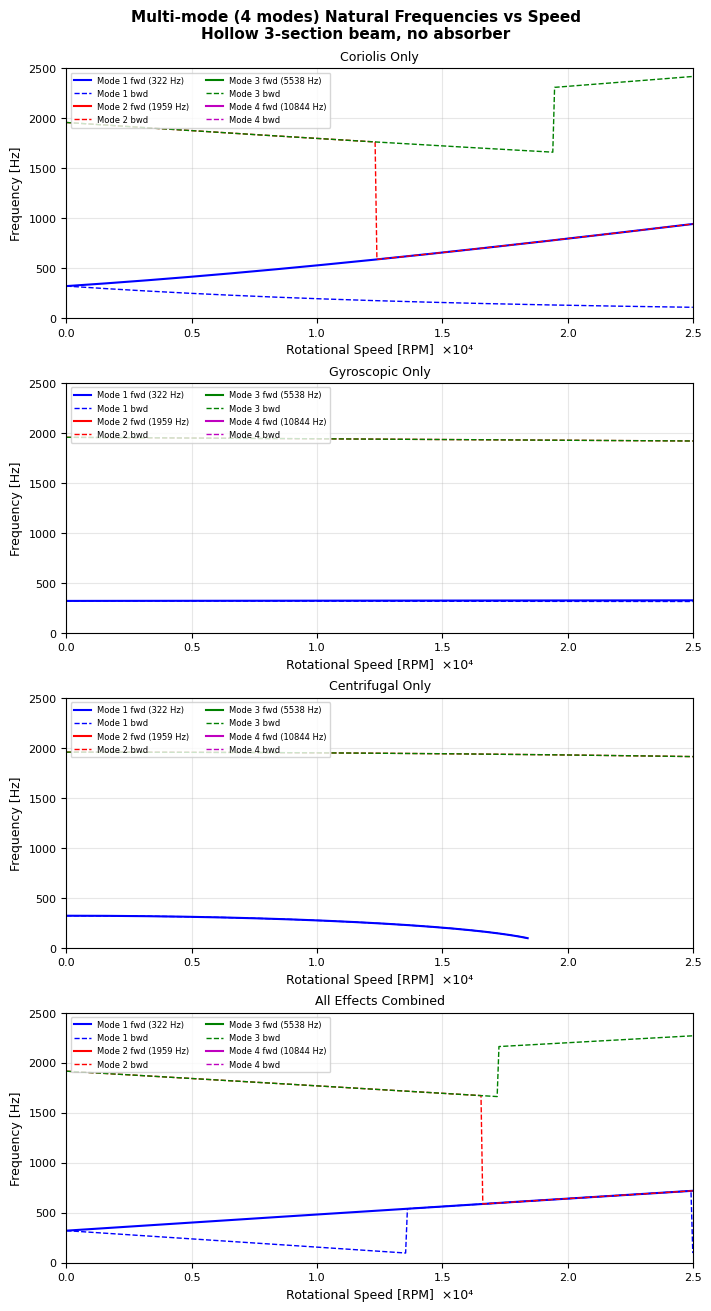

Displayed FigA


<Figure size 640x480 with 0 Axes>

In [ ]:
# =================== FIG A: Natural Freqs (no absorber, all modes) ===================
fig_A, axes_A = plt.subplots(4,1, figsize=(7,13), constrained_layout=True)
fig_A.suptitle(
    f'Multi-mode ({N_MODES} modes) Natural Frequencies vs Speed\n'
    'Hollow 3-section beam, no absorber',
    fontsize=11, fontweight='bold')

datasets_A = [(f_cor_noabs,'Coriolis Only'),(f_gyro_noabs,'Gyroscopic Only'),
              (f_cent_noabs,'Centrifugal Only'),(f_all_noabs,'All Effects Combined')]
mode_colors = ['b','r','g','m','c']

for ax,(fdata,title) in zip(axes_A, datasets_A):
    # Extract all distinct branches up to 2500 Hz
    for mode_idx in range(N_MODES):
        fw_m, bw_m = [], []
        for flist in fdata:
            # Collect frequencies near this mode's zero-speed value
            fn0 = fn[mode_idx]
            near = sorted([f for f in flist if 0.3*fn0 < f < 3.0*fn0])
            if len(near) >= 2:
                bw_m.append(near[0]); fw_m.append(near[-1])
            elif len(near) == 1:
                bw_m.append(near[0]); fw_m.append(near[0])
            else:
                bw_m.append(np.nan); fw_m.append(np.nan)
        lbl_fw = f'Mode {mode_idx+1} fwd ({fn[mode_idx]:.0f} Hz)'
        lbl_bw = f'Mode {mode_idx+1} bwd'
        ax.plot(spd_k, fw_m, color=mode_colors[mode_idx], ls='-',  lw=1.5, label=lbl_fw)
        ax.plot(spd_k, bw_m, color=mode_colors[mode_idx], ls='--', lw=1.0, label=lbl_bw)
    ax.set_xlabel('Rotational Speed [RPM]  ×10⁴')
    ax.set_ylabel('Frequency [Hz]')
    ax.set_title(title, fontsize=9)
    ax.set_xlim(0, 2.5); ax.set_ylim(0, 2500)
    ax.legend(fontsize=6, ncol=2, loc='upper left'); ax.grid(True, alpha=0.3)

plt.show()
plt.clf()
print("Displayed FigA")

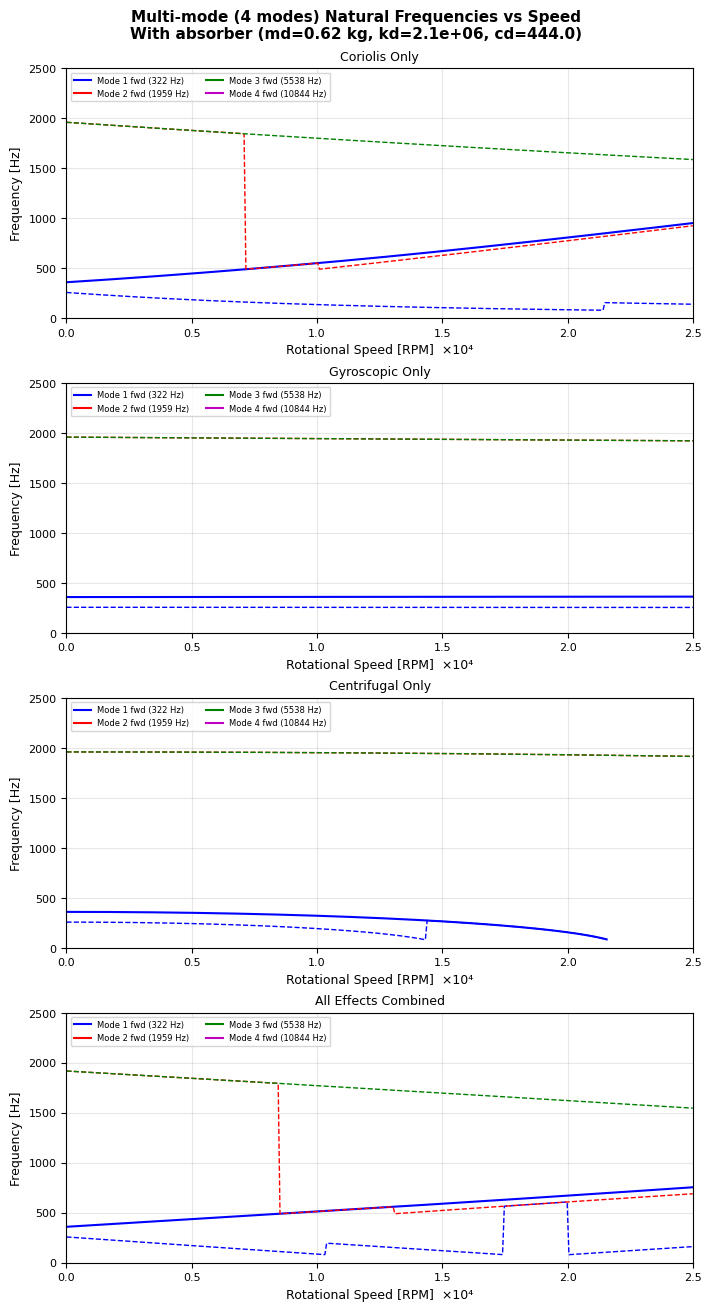

Displayed FigB


<Figure size 640x480 with 0 Axes>

In [ ]:
# =================== FIG B: Natural Freqs (with absorber) ===================
fig_B, axes_B = plt.subplots(4,1, figsize=(7,13), constrained_layout=True)
fig_B.suptitle(
    f'Multi-mode ({N_MODES} modes) Natural Frequencies vs Speed\n'
    f'With absorber (md={md_opt} kg, kd={kd_opt:.1e}, cd={cd_opt})',
    fontsize=11, fontweight='bold')

datasets_B = [(f_cor_abs,'Coriolis Only'),(f_gyro_abs,'Gyroscopic Only'),
              (f_cent_abs,'Centrifugal Only'),(f_all_abs,'All Effects Combined')]
for ax,(fdata,title) in zip(axes_B, datasets_B):
    for mode_idx in range(N_MODES):
        fw_m, bw_m = [], []
        fn0 = fn[mode_idx]
        for flist in fdata:
            near = sorted([f for f in flist if 0.25*fn0 < f < 3.5*fn0])
            if len(near)>=2: bw_m.append(near[0]); fw_m.append(near[-1])
            elif len(near)==1: bw_m.append(near[0]); fw_m.append(near[0])
            else: bw_m.append(np.nan); fw_m.append(np.nan)
        lbl_fw = f'Mode {mode_idx+1} fwd ({fn[mode_idx]:.0f} Hz)'
        ax.plot(spd_k, fw_m, color=mode_colors[mode_idx], ls='-',  lw=1.5, label=lbl_fw)
        ax.plot(spd_k, bw_m, color=mode_colors[mode_idx], ls='--', lw=1.0)
    ax.set_xlabel('Rotational Speed [RPM]  ×10⁴')
    ax.set_ylabel('Frequency [Hz]')
    ax.set_title(title, fontsize=9)
    ax.set_xlim(0, 2.5); ax.set_ylim(0, 2500)
    ax.legend(fontsize=6, ncol=2, loc='upper left'); ax.grid(True, alpha=0.3)

plt.show()
plt.clf()
print("Displayed FigB")

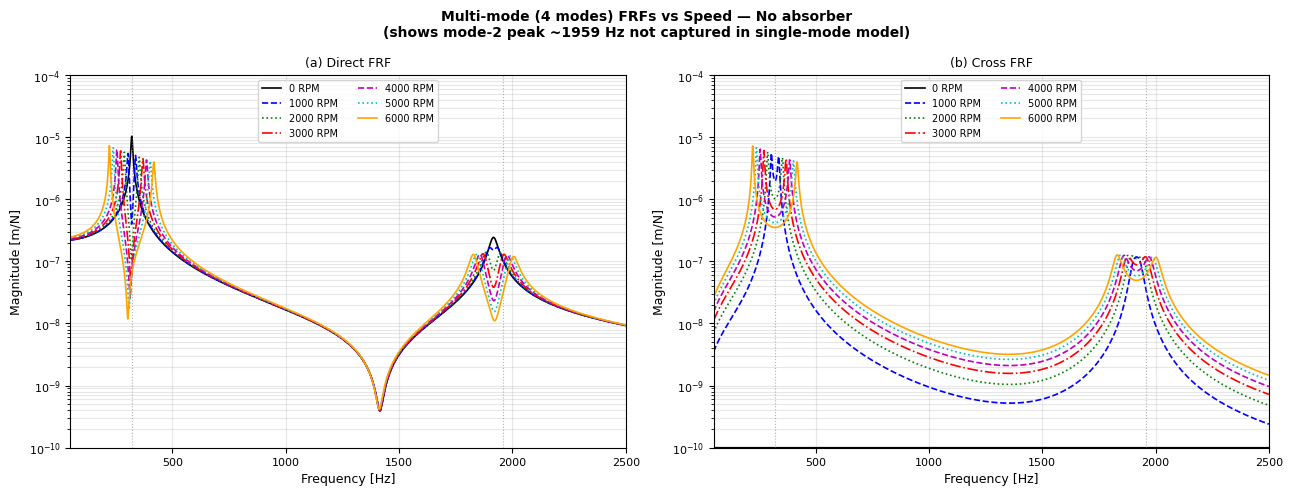

Displayed FigC


<Figure size 640x480 with 0 Axes>

In [ ]:
# =================== FIG C: Multi-mode FRF vs speed (no absorber) ===================
fig_C, (axC1, axC2) = plt.subplots(1,2, figsize=(13,5))
fig_C.suptitle(f'Multi-mode ({N_MODES} modes) FRFs vs Speed — No absorber\n'
               '(shows mode-2 peak ~1959 Hz not captured in single-mode model)',
               fontsize=10, fontweight='bold')
clrs=['k','b','g','r','m','c','orange']
ls_list=['-','--',':','-.','--',':','-']
lbls=[f'{r} RPM' for r in speeds_fig]
for i,(Hd,Hc) in enumerate(zip(FRF_d_noabs,FRF_c_noabs)):
    axC1.semilogy(freqs_frf,np.clip(Hd,1e-10,None),color=clrs[i],ls=ls_list[i],lw=1.2,label=lbls[i])
    axC2.semilogy(freqs_frf,np.clip(Hc,1e-10,None),color=clrs[i],ls=ls_list[i],lw=1.2,label=lbls[i])
for ax,t in [(axC1,'(a) Direct FRF'),(axC2,'(b) Cross FRF')]:
    ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('Magnitude [m/N]')
    ax.set_title(t); ax.set_xlim(50,2500); ax.set_ylim(1e-10,1e-4)
    ax.legend(fontsize=7,ncol=2); ax.grid(True,which='both',alpha=0.3)
    ax.axvline(fn[0],color='gray',ls=':',lw=0.8,alpha=0.6,label=f'Mode1 {fn[0]:.0f}Hz')
    ax.axvline(fn[1],color='gray',ls=':',lw=0.8,alpha=0.6,label=f'Mode2 {fn[1]:.0f}Hz')
plt.tight_layout()
plt.show()
plt.clf()
print("Displayed FigC")

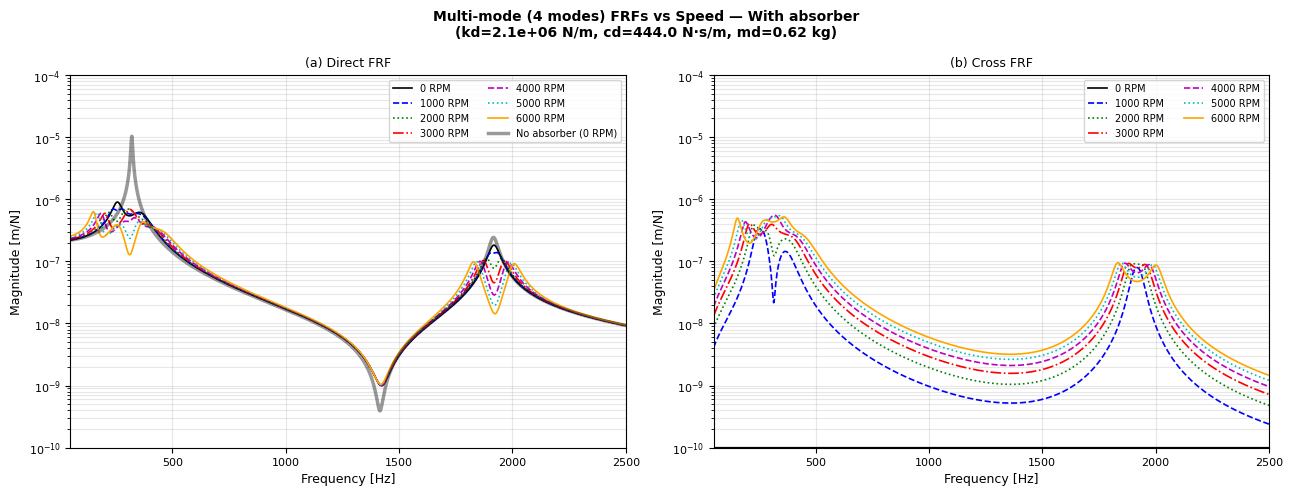

Displayed FigD


<Figure size 640x480 with 0 Axes>

In [ ]:
# =================== FIG D: Multi-mode FRF with absorber ===================
fig_D, (axD1, axD2) = plt.subplots(1,2, figsize=(13,5))
fig_D.suptitle(f'Multi-mode ({N_MODES} modes) FRFs vs Speed — With absorber\n'
               f'(kd={kd_opt:.1e} N/m, cd={cd_opt} N·s/m, md={md_opt} kg)',
               fontsize=10, fontweight='bold')
for i,(Hd,Hc) in enumerate(zip(FRF_d_abs,FRF_c_abs)):
    axD1.semilogy(freqs_frf,np.clip(Hd,1e-10,None),color=clrs[i],ls=ls_list[i],lw=1.2,label=lbls[i])
    axD2.semilogy(freqs_frf,np.clip(Hc,1e-10,None),color=clrs[i],ls=ls_list[i],lw=1.2,label=lbls[i])
axD1.semilogy(freqs_frf,np.clip(np.abs(Hxx_ref),1e-10,None),'k-',lw=2.5,label='No absorber (0 RPM)',alpha=0.4)
for ax,t in [(axD1,'(a) Direct FRF'),(axD2,'(b) Cross FRF')]:
    ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('Magnitude [m/N]')
    ax.set_title(t); ax.set_xlim(50,2500); ax.set_ylim(1e-10,1e-4)
    ax.legend(fontsize=7,ncol=2); ax.grid(True,which='both',alpha=0.3)
plt.tight_layout()
plt.show()
plt.clf()
print("Displayed FigD")

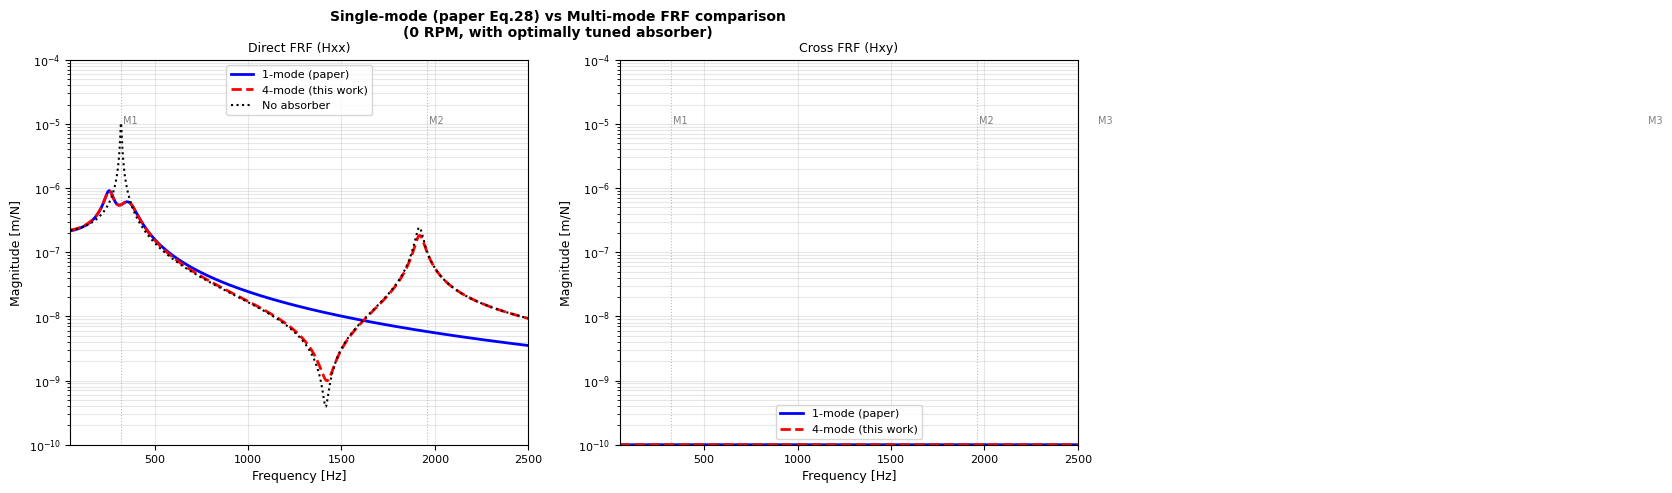

Displayed FigE


<Figure size 640x480 with 0 Axes>

In [ ]:
# =================== FIG E: Single-mode vs multi-mode FRF comparison ===================
fig_E, (axE1, axE2) = plt.subplots(1,2, figsize=(13,5))
fig_E.suptitle('Single-mode (paper Eq.28) vs Multi-mode FRF comparison\n'
               '(0 RPM, with optimally tuned absorber)',
               fontsize=10, fontweight='bold')
axE1.semilogy(freqs_frf,np.clip(np.abs(H1_xx),1e-10,None),'b-',lw=2,label='1-mode (paper)')
axE1.semilogy(freqs_frf,np.clip(np.abs(HN_xx),1e-10,None),'r--',lw=2,label=f'{N_MODES}-mode (this work)')
axE1.semilogy(freqs_frf,np.clip(np.abs(Hxx_ref),1e-10,None),'k:',lw=1.5,label='No absorber')
axE2.semilogy(freqs_frf,np.clip(np.abs(H1_xy),1e-10,None),'b-',lw=2,label='1-mode (paper)')
axE2.semilogy(freqs_frf,np.clip(np.abs(HN_xy),1e-10,None),'r--',lw=2,label=f'{N_MODES}-mode (this work)')
for ax,t in [(axE1,'Direct FRF (Hxx)'),(axE2,'Cross FRF (Hxy)')]:
    ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('Magnitude [m/N]')
    ax.set_title(t); ax.set_xlim(50,2500); ax.set_ylim(1e-10,1e-4)
    ax.legend(fontsize=8); ax.grid(True,which='both',alpha=0.3)
    for m in range(min(N_MODES,3)):
        ax.axvline(fn[m],color='gray',ls=':',lw=0.8,alpha=0.5)
        ax.text(fn[m]+10,1e-5,f'M{m+1}',fontsize=7,color='gray')
plt.tight_layout()
plt.show()
plt.clf()
print("Displayed FigE")

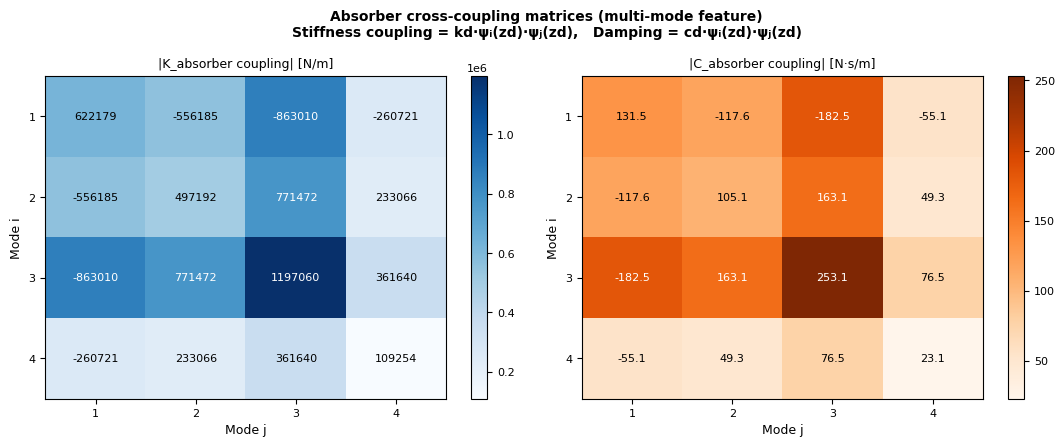

Displayed FigF


<Figure size 640x480 with 0 Axes>

In [ ]:
# =================== FIG F: Absorber cross-coupling heatmap ===================
fig_F, (axF1, axF2) = plt.subplots(1,2, figsize=(11,4.5))
fig_F.suptitle('Absorber cross-coupling matrices (multi-mode feature)\n'
               'Stiffness coupling = kd·ψᵢ(zd)·ψⱼ(zd),   Damping = cd·ψᵢ(zd)·ψⱼ(zd)',
               fontsize=10, fontweight='bold')
K_coup = kd_opt * coupling_matrix
C_coup = cd_opt * coupling_matrix
im1 = axF1.imshow(np.abs(K_coup), cmap='Blues', aspect='auto')
axF1.set_title('|K_absorber coupling| [N/m]')
axF1.set_xlabel('Mode j'); axF1.set_ylabel('Mode i')
axF1.set_xticks(range(N_MODES)); axF1.set_yticks(range(N_MODES))
axF1.set_xticklabels([f'{i+1}' for i in range(N_MODES)])
axF1.set_yticklabels([f'{i+1}' for i in range(N_MODES)])
for i in range(N_MODES):
    for j in range(N_MODES):
        axF1.text(j,i,f'{K_coup[i,j]:.0f}',ha='center',va='center',fontsize=8,
                  color='white' if abs(K_coup[i,j])>0.6*K_coup.max() else 'black')
plt.colorbar(im1,ax=axF1)

im2 = axF2.imshow(np.abs(C_coup), cmap='Oranges', aspect='auto')
axF2.set_title('|C_absorber coupling| [N·s/m]')
axF2.set_xlabel('Mode j'); axF2.set_ylabel('Mode i')
axF2.set_xticks(range(N_MODES)); axF2.set_yticks(range(N_MODES))
axF2.set_xticklabels([f'{i+1}' for i in range(N_MODES)])
axF2.set_yticklabels([f'{i+1}' for i in range(N_MODES)])
for i in range(N_MODES):
    for j in range(N_MODES):
        axF2.text(j,i,f'{C_coup[i,j]:.1f}',ha='center',va='center',fontsize=8,
                  color='white' if abs(C_coup[i,j])>0.6*C_coup.max() else 'black')
plt.colorbar(im2,ax=axF2)
plt.tight_layout()
plt.show()
plt.clf()
print("Displayed FigF")

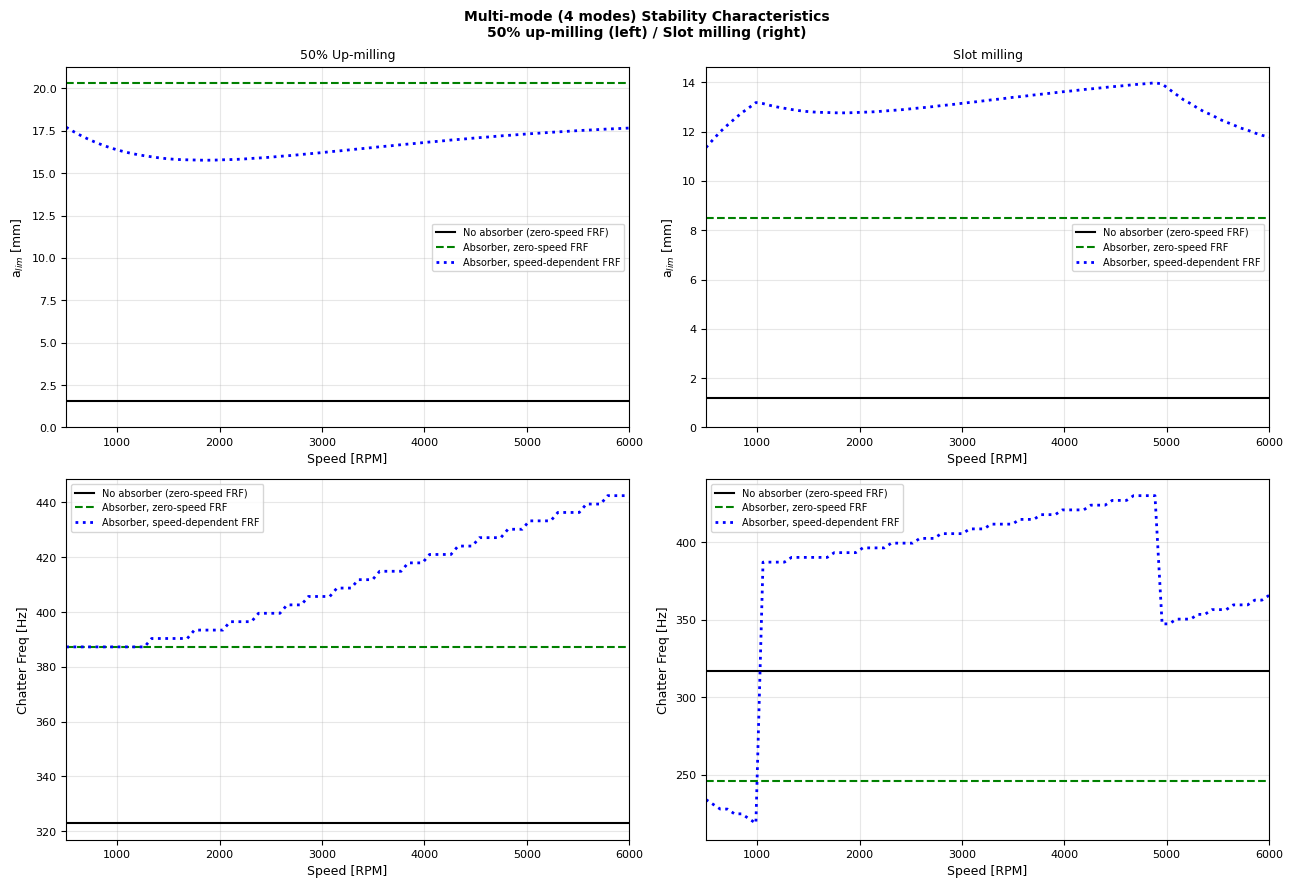

Displayed FigG


<Figure size 640x480 with 0 Axes>

In [ ]:
# =================== FIG G: Stability lobes ===================
fig_G, ax_G = plt.subplots(2,2, figsize=(13,9))
fig_G.suptitle(f'Multi-mode ({N_MODES} modes) Stability Characteristics\n'
               '50% up-milling (left) / Slot milling (right)',
               fontsize=10, fontweight='bold')
stab_labs=['No absorber (zero-speed FRF)','Absorber, zero-speed FRF','Absorber, speed-dependent FRF']
stab_clr=['k','g','b']; stab_ls=['-','--',':']; stab_lw=[1.5,1.5,2]
up_sets=[al_noabs_up,al_abs_up0,al_abs_upS]; sl_sets=[al_noabs_sl,al_abs_sl0,al_abs_slS]
up_cf=[cf_noabs_up,cf_abs_up0,cf_abs_upS];   sl_cf=[cf_noabs_sl,cf_abs_sl0,cf_abs_slS]
for i,(l,c,ls,lw) in enumerate(zip(stab_labs,stab_clr,stab_ls,stab_lw)):
    ax_G[0,0].plot(speeds_stab,up_sets[i],color=c,ls=ls,lw=lw,label=l)
    ax_G[0,1].plot(speeds_stab,sl_sets[i],color=c,ls=ls,lw=lw,label=l)
    ax_G[1,0].plot(speeds_stab,up_cf[i],  color=c,ls=ls,lw=lw,label=l)
    ax_G[1,1].plot(speeds_stab,sl_cf[i],  color=c,ls=ls,lw=lw,label=l)
ax_G[0,0].set_ylabel('a$_{lim}$ [mm]'); ax_G[0,1].set_ylabel('a$_{lim}$ [mm]')
ax_G[1,0].set_ylabel('Chatter Freq [Hz]'); ax_G[1,1].set_ylabel('Chatter Freq [Hz]')
ax_G[0,0].set_title('50% Up-milling'); ax_G[0,1].set_title('Slot milling')
for ax in ax_G.flat:
    ax.set_xlabel('Speed [RPM]'); ax.set_xlim(500,6000)
    ax.grid(True,alpha=0.3); ax.legend(fontsize=7)
ax_G[0,0].set_ylim(bottom=0); ax_G[0,1].set_ylim(bottom=0)
plt.tight_layout()
plt.show()
plt.clf()
print("Displayed FigG")

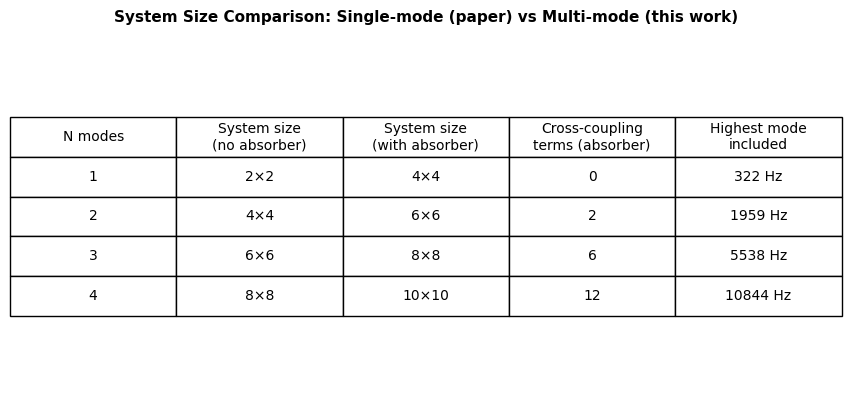

Displayed FigH


<Figure size 640x480 with 0 Axes>

In [ ]:
# =================== FIG H: System size comparison table ===================
fig_H, ax_H = plt.subplots(figsize=(9,4))
ax_H.axis('off')
n_vals = [1,2,3,4]
rows = []
for n in n_vals:
    sz_noabs = 2*n
    sz_abs   = 2*(n+1)
    cross_terms = n**2 - n   # off-diagonal absorber couplings (per block)
    rows.append([f'{n}', f'{sz_noabs}×{sz_noabs}', f'{sz_abs}×{sz_abs}',
                 f'{cross_terms}', f'{fn[n-1]:.0f} Hz'])
col_labels = ['N modes','System size\n(no absorber)','System size\n(with absorber)',
              'Cross-coupling\nterms (absorber)','Highest mode\nincluded']
tbl = ax_H.table(cellText=rows, colLabels=col_labels,
                  loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
tbl.scale(1.4, 2.2)
ax_H.set_title('System Size Comparison: Single-mode (paper) vs Multi-mode (this work)',
               fontsize=11, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
plt.clf()
print("Displayed FigH")

In [ ]:
# =============================================================================
# 11. SUMMARY PRINTOUT
# =============================================================================
print("\n" + "="*65)
print("MULTI-MODE RESULTS SUMMARY")
print("="*65)
print(f"N_MODES = {N_MODES}  (paper uses N=1)")
print(f"\nBeam natural frequencies (3-section hollow beam):")
for i in range(N_MODES):
    print(f"  Mode {i+1}: fn = {fn[i]:.2f} Hz")
print(f"\nAbsorber coupling: PSI_zd = {np.round(PSI_zd,4)}")
print(f"\nStiffness coupling kd·PSI_i(zd)·PSI_j(zd):")
print(np.round(kd_opt*coupling_matrix,1))
print(f"\nDamping coupling cd·PSI_i(zd)·PSI_j(zd):")
print(np.round(cd_opt*coupling_matrix,3))
print(f"\nNote: single-mode uses only the [0,0] entry of these matrices.")
print(f"      Multi-mode uses the full {N_MODES}×{N_MODES} block.")
print(f"\nSystem DOFs comparison:")
print(f"  Paper (1 mode + absorber): 4 DOFs")
print(f"  This work ({N_MODES} modes + absorber): {2*(N_MODES+1)} DOFs")
print("\nAll figures are now displayed in the notebook.")


MULTI-MODE RESULTS SUMMARY
N_MODES = 4  (paper uses N=1)

Beam natural frequencies (3-section hollow beam):
  Mode 1: fn = 321.89 Hz
  Mode 2: fn = 1958.97 Hz
  Mode 3: fn = 5538.19 Hz
  Mode 4: fn = 10844.30 Hz

Absorber coupling: PSI_zd = [ 0.5443 -0.4866 -0.755  -0.2281]

Stiffness coupling kd·PSI_i(zd)·PSI_j(zd):
[[ 622178.8 -556185.3 -863009.6 -260720.7]
 [-556185.3  497191.6  771471.6  233066.5]
 [-863009.6  771471.6 1197060.5  361639.5]
 [-260720.7  233066.5  361639.5  109253.6]]

Damping coupling cd·PSI_i(zd)·PSI_j(zd):
[[ 131.546 -117.593 -182.465  -55.124]
 [-117.593  105.121  163.111   49.277]
 [-182.465  163.111  253.093   76.461]
 [ -55.124   49.277   76.461   23.099]]

Note: single-mode uses only the [0,0] entry of these matrices.
      Multi-mode uses the full 4×4 block.

System DOFs comparison:
  Paper (1 mode + absorber): 4 DOFs
  This work (4 modes + absorber): 10 DOFs

All figures are now displayed in the notebook.


In [ ]:
# ============================================================
# STABILITY PLOT:
# Tool holder WITHOUT absorber vs WITH absorber
# Absorber tuning methods:
# 1) Den Hartog method
# 2) Proposed zero-speed dynamics
# 3) Proposed non-zero-speed dynamics
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [ ]:
# ------------------------------------------------------------
# USER-CONTROLLED SETTINGS
# ------------------------------------------------------------

md_use = 0.62          # absorber mass [kg]
case = "up_50"        # "up_50" or "slot"

speed_range = np.linspace(600, 6000, 90)     # spindle speed [RPM]
freqs_stab = np.linspace(50, 520, 700)       # chatter frequency sweep [Hz]

In [ ]:
# ------------------------------------------------------------
# DEN HARTOG TUNING
# ------------------------------------------------------------

def den_hartog_tuning(md_):
    """
    Den Hartog fixed-point tuning.
    Uses modal mass Mm and first natural frequency wn1 from uploaded file.
    """
    mu = md_ / Mm[0]

    f_ratio = 1.0 / (1.0 + mu)
    zeta_d = np.sqrt((3 * mu) / (8 * (1 + mu)))

    wd = f_ratio * omega_n[0]

    kd = md_ * wd**2
    cd = 2 * zeta_d * md_ * wd

    return kd, cd

In [ ]:
# ------------------------------------------------------------
# STABILITY LIMIT AT ONE SPEED
# ------------------------------------------------------------

def stability_at_speed(rpm, with_absorber=False, kd=0, cd=0, md_=0,
                       speed_dependent=False, case="up_50"):
    """
    Calculates limiting axial depth of cut at one spindle speed.

    speed_dependent = False:
        FRF calculated at Omega = 0
        Used for zero-speed dynamics.

    speed_dependent = True:
        FRF calculated at actual spindle speed
        Used for non-zero-speed dynamics.
    """

    if speed_dependent:
        Omega = rpm * 2 * np.pi / 60
    else:
        Omega = 0.0

    Hxx, Hxy = compute_FRF(
        freqs_stab,
        Omega,
        with_absorber=with_absorber,
        kd=kd,
        cd=cd,
        md_=md_
    )

    alim, chatter_freq = stability_limit(Hxx, Hxy, case)

    return alim * 1000, chatter_freq      # mm, Hz

In [ ]:
# ------------------------------------------------------------
# OBJECTIVE FUNCTION FOR PROPOSED ZERO-SPEED TUNING
# ------------------------------------------------------------

def objective_zero_speed(log_params, md_, case):
    """
    Proposed tuning based on zero-speed dynamics.
    Optimizes kd and cd to maximize average stability limit,
    but FRF is always calculated at Omega = 0.
    """

    kd = 10 ** log_params[0]
    cd = 10 ** log_params[1]

    if kd < 5e4 or kd > 5e7 or cd < 10 or cd > 2000:
        return 1e9

    alim_values = []

    for rpm in speed_range:
        alim, _ = stability_at_speed(
            rpm,
            with_absorber=True,
            kd=kd,
            cd=cd,
            md_=md_,
            speed_dependent=False,
            case=case
        )
        alim_values.append(alim)

    return -np.mean(alim_values)

In [ ]:
# ------------------------------------------------------------
# OBJECTIVE FUNCTION FOR PROPOSED NON-ZERO-SPEED TUNING
# ------------------------------------------------------------

def objective_nonzero_speed(log_params, md_, case):
    """
    Proposed tuning based on non-zero-speed dynamics.
    Optimizes kd and cd using speed-dependent FRFs.
    """

    kd = 10 ** log_params[0]
    cd = 10 ** log_params[1]

    if kd < 5e4 or kd > 5e7 or cd < 10 or cd > 2000:
        return 1e9

    alim_values = []

    for rpm in speed_range:
        alim, _ = stability_at_speed(
            rpm,
            with_absorber=True,
            kd=kd,
            cd=cd,
            md_=md_,
            speed_dependent=True,
            case=case
        )
        alim_values.append(alim)

    return -np.mean(alim_values)

In [ ]:
# ------------------------------------------------------------
# OPTIMIZATION WRAPPER
# ------------------------------------------------------------

def optimize_absorber_zero_speed(md_, case):
    x0 = [np.log10(2e6), np.log10(400)]

    res = minimize(
        objective_zero_speed,
        x0,
        args=(md_, case),
        method="Nelder-Mead",
        options={
            "maxiter": 200,
            "maxfev": 600,
            "xatol": 0.03,
            "fatol": 1e-6
        }
    )

    kd = 10 ** res.x[0]
    cd = 10 ** res.x[1]

    return kd, cd


def optimize_absorber_nonzero_speed(md_, case):
    x0 = [np.log10(2e6), np.log10(400)]

    res = minimize(
        objective_nonzero_speed,
        x0,
        args=(md_, case),
        method="Nelder-Mead",
        options={
            "maxiter": 200,
            "maxfev": 600,
            "xatol": 0.03,
            "fatol": 1e-6
        }
    )

    kd = 10 ** res.x[0]
    cd = 10 ** res.x[1]

    return kd, cd

In [ ]:
# ------------------------------------------------------------
# CALCULATE ABSORBER PARAMETERS
# ------------------------------------------------------------

kd_dh, cd_dh = den_hartog_tuning(md_use)

kd_zero, cd_zero = optimize_absorber_zero_speed(md_use, case)

kd_nonzero, cd_nonzero = optimize_absorber_nonzero_speed(md_use, case)

print("\n========== ABSORBER PARAMETERS ==========")
print(f"Absorber mass md = {md_use:.3f} kg")

print("\nDen Hartog method:")
print(f"kd = {kd_dh:.4e} N/m")
print(f"cd = {cd_dh:.4f} Ns/m")

print("\nProposed zero-speed dynamics:")
print(f"kd = {kd_zero:.4e} N/m")
print(f"cd = {cd_zero:.4f} Ns/m")

print("\nProposed non-zero-speed dynamics:")
print(f"kd = {kd_nonzero:.4e} N/m")
print(f"cd = {cd_nonzero:.4f} Ns/m")

In [ ]:
# ------------------------------------------------------------
# STABILITY CURVES
# ------------------------------------------------------------

al_no_abs = []
cf_no_abs = []

al_dh = []
cf_dh = []

al_zero = []
cf_zero = []

al_nonzero = []
cf_nonzero = []

for rpm in speed_range:

    # 1. Tool without absorber
    a, f = stability_at_speed(
        rpm,
        with_absorber=False,
        speed_dependent=False,
        case=case
    )
    al_no_abs.append(a)
    cf_no_abs.append(f)

    # 2. Den Hartog absorber, zero-speed dynamics
    a, f = stability_at_speed(
        rpm,
        with_absorber=True,
        kd=kd_dh,
        cd=cd_dh,
        md_=md_use,
        speed_dependent=False,
        case=case
    )
    al_dh.append(a)
    cf_dh.append(f)

    # 3. Proposed absorber, zero-speed dynamics
    a, f = stability_at_speed(
        rpm,
        with_absorber=True,
        kd=kd_zero,
        cd=cd_zero,
        md_=md_use,
        speed_dependent=False,
        case=case
    )
    al_zero.append(a)
    cf_zero.append(f)

    # 4. Proposed absorber, non-zero-speed dynamics
    a, f = stability_at_speed(
        rpm,
        with_absorber=True,
        kd=kd_nonzero,
        cd=cd_nonzero,
        md_=md_use,
        speed_dependent=True,
        case=case
    )
    al_nonzero.append(a)
    cf_nonzero.append(f)


al_no_abs = np.array(al_no_abs)
al_dh = np.array(al_dh)
al_zero = np.array(al_zero)
al_nonzero = np.array(al_nonzero)

cf_no_abs = np.array(cf_no_abs)
cf_dh = np.array(cf_dh)
cf_zero = np.array(cf_zero)
cf_nonzero = np.array(cf_nonzero)

In [ ]:
# ------------------------------------------------------------
# PLOT STABILITY LIMIT AND CHATTER FREQUENCY
# ------------------------------------------------------------

fig, ax = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

fig.suptitle(
    "Stability comparison: No absorber vs absorber tuning methods",
    fontsize=13,
    fontweight="bold"
)

# Stability limit plot
ax[0].plot(speed_range, al_no_abs, "k-", linewidth=2,
           label="Without absorber")

ax[0].plot(speed_range, al_dh, "g--", linewidth=2,
           label="With absorber: Den Hartog")

ax[0].plot(speed_range, al_zero, "r-.", linewidth=2,
           label="With absorber: Proposed zero-speed dynamics")

ax[0].plot(speed_range, al_nonzero, "b:", linewidth=2.5,
           label="With absorber: Proposed non-zero-speed dynamics")

ax[0].set_ylabel(r"Limiting axial depth $a_{lim}$ [mm]")
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=8)
ax[0].set_ylim(bottom=0)

# Chatter frequency plot
ax[1].plot(speed_range, cf_no_abs, "k-", linewidth=2,
           label="Without absorber")

ax[1].plot(speed_range, cf_dh, "g--", linewidth=2,
           label="With absorber: Den Hartog")

ax[1].plot(speed_range, cf_zero, "r-.", linewidth=2,
           label="With absorber: Proposed zero-speed dynamics")

ax[1].plot(speed_range, cf_nonzero, "b:", linewidth=2.5,
           label="With absorber: Proposed non-zero-speed dynamics")

ax[1].set_xlabel("Spindle speed [RPM]")
ax[1].set_ylabel("Chatter frequency [Hz]")
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# OPTIONAL: PRINT AVERAGE IMPROVEMENT
# ------------------------------------------------------------

print("\n========== AVERAGE STABILITY LIMIT ==========")
print(f"Without absorber                 : {np.mean(al_no_abs):.4f} mm")
print(f"Den Hartog absorber              : {np.mean(al_dh):.4f} mm")
print(f"Proposed zero-speed dynamics     : {np.mean(al_zero):.4f} mm")
print(f"Proposed non-zero-speed dynamics : {np.mean(al_nonzero):.4f} mm")

print("\n========== IMPROVEMENT OVER NO ABSORBER ==========")
print(f"Den Hartog              : {np.mean(al_dh) / np.mean(al_no_abs):.2f} x")
print(f"Proposed zero-speed     : {np.mean(al_zero) / np.mean(al_no_abs):.2f} x")
print(f"Proposed non-zero-speed : {np.mean(al_nonzero) / np.mean(al_no_abs):.2f} x")